# AgriMada - Entraînement d'un modèle de détection de maladies du riz
Ce notebook utilise MobileNetV2 avec transfer learning pour classer 3 maladies du riz.
Il inclut l'augmentation de données, des callbacks et la conversion en TFLite.

## 1. Installation des dépendances

In [ ]:
!pip install -q kagglehub tensorflow matplotlib seaborn

 ## 2. Import des bibliothèques

In [ ]:
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import pathlib

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 3. Téléchargement du dataset Rice Leaf Diseases

In [ ]:
# Télécharger la dernière version du dataset
path = kagglehub.dataset_download("vbookshelf/rice-leaf-diseases")
print("Dataset path:", path)

100%|██████████| 36.7M/36.7M [00:00<00:00, 167MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/vbookshelf/rice-leaf-diseases/versions/1


In [ ]:
# Lister les fichiers
data_dir = os.path.join(path, 'rice_leaf_diseases')
print("Contenu :", os.listdir(data_dir))

# Afficher les noms des classes (dossiers)
class_names = sorted(os.listdir(data_dir))
print("Classes :", class_names)

Contenu : ['Brown spot', 'Leaf smut', 'Bacterial leaf blight']
Classes : ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


## 4. Préparation des données avec augmentation

In [ ]:
# Paramètres
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123
AUTOTUNE = tf.data.AUTOTUNE

# Chargement des images avec split train/validation (80/20)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Normalisation (valeurs entre 0 et 1)
normalization_layer = layers.Rescaling(1./255)

# Augmentation de données (uniquement pour l'entraînement)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Appliquer normalisation et augmentation sur le train_ds
train_ds = train_ds.map(lambda x, y: (normalization_layer(data_augmentation(x, training=True)), y),
                        num_parallel_calls=AUTOTUNE)

# Pour la validation, seulement normalisation
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y),
                    num_parallel_calls=AUTOTUNE)

# Optimisation des performances
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Vérification du nombre de classes
num_classes = len(class_names)
print("Nombre de classes :", num_classes)

Found 120 files belonging to 3 classes.
Using 96 files for training.
Found 120 files belonging to 3 classes.
Using 24 files for validation.
Nombre de classes : 3


## 5. Construction du modèle avec MobileNetV2

In [ ]:
# Charger le modèle de base pré-entraîné sur ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Geler les poids

# Ajouter la tête de classification
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Compilation et callbacks

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks pour éviter le surapprentissage
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-7)
]

## 7. Entraînement

In [ ]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4271 - loss: 1.5689 - val_accuracy: 0.7500 - val_loss: 0.8206 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5833 - loss: 1.1409 - val_accuracy: 0.6667 - val_loss: 0.7786 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.6667 - loss: 0.7629 - val_accuracy: 0.7083 - val_loss: 0.6837 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7500 - loss: 0.5688 - val_accuracy: 0.7500 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7708 - loss: 0.5088 - val_accuracy: 0.7917 - val_loss: 0.5743 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8542 - loss: 0.4006 - val_accuracy: 0.8333 - val_loss: 0.4978 - learning_rate: 0.0010
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9271 - loss: 0.2676 - val_accuracy: 0.8750 - val_loss: 0

## 8. Visualisation des courbes d'apprentissage

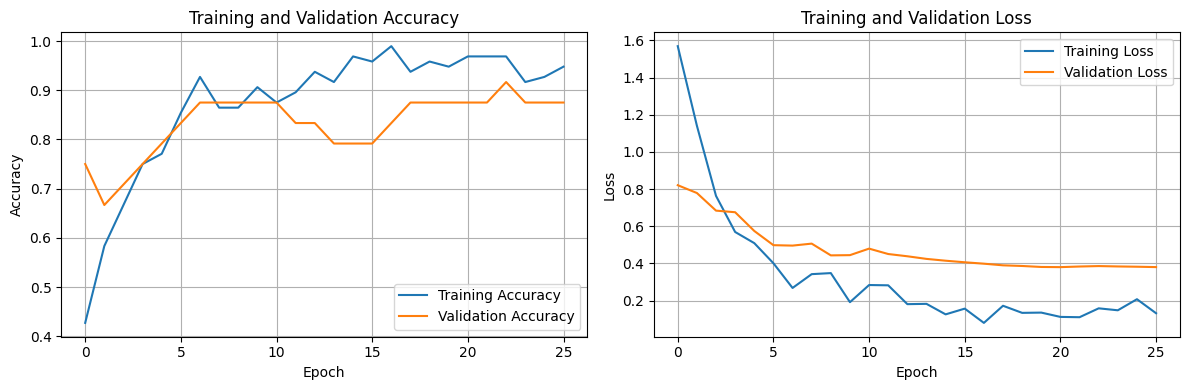

In [ ]:
# Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 9. Évaluation sur le jeu de validation

In [ ]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation Loss: {loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step - accuracy: 0.8750 - loss: 0.3796
Validation Accuracy: 0.8750
Validation Loss: 0.3796


## 10. Matrice de confusion

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


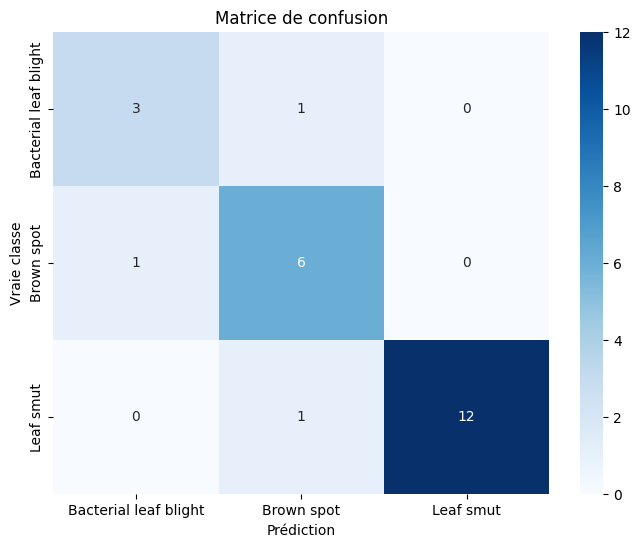

In [ ]:
# Récupérer les vraies étiquettes et les prédictions
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Afficher
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prédiction')
plt.ylabel('Vraie classe')
plt.title('Matrice de confusion')
plt.show()

## 11. Conversion en TensorFlow Lite

In [ ]:
# Convertir le modèle
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Quantification par défaut
tflite_model = converter.convert()

# Sauvegarder dans le répertoire courant
tflite_path = 'agrimada_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"Modèle TFLite sauvegardé sous : {tflite_path}")

# Sauvegarder aussi les labels
labels_path = 'labels.txt'
with open(labels_path, 'w') as f:
    for label in class_names:
        f.write(label + '\n')

print(f"Labels sauvegardés sous : {labels_path}")

Saved artifact at '/tmp/tmp4sblo4kf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_159')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137513097254224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097255376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097256336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097255952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097255184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097254800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097258256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097258448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097257296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137513097255568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1375130972

## 12. Sauvegarde sur Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Créer un dossier pour le projet (si nécessaire)
!mkdir -p /content/drive/MyDrive/AgriMada

# Copier les fichiers
!cp agrimada_model.tflite /content/drive/MyDrive/AgriMada/
!cp labels.txt /content/drive/MyDrive/AgriMada/

print("Fichiers copiés dans Google Drive/AgriMada/")

Mounted at /content/drive
Fichiers copiés dans Google Drive/AgriMada/


 ## 13. Test rapide du modèle TFLite

In [ ]:
# Installer le nouveau package (à exécuter une seule fois)
!pip install -q ai-edge-litert

# Utiliser LiteRT au lieu de tf.lite
from ai_edge_litert.interpreter import Interpreter
import numpy as np

# Charger le modèle TFLite (maintenant LiteRT)
interpreter = Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

# Obtenir les détails d'entrée/sortie
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

# Fonction de prédiction (identique, mais utilise le nouvel interpreter)
def predict_tflite(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, 0) / 255.0  # normalisation

    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = np.argmax(output[0])
    confidence = np.max(output[0])
    return class_names[predicted_class], confidence

# Tester sur une image
for images, labels in val_ds.take(1):
    sample_image = images[0].numpy()
    sample_label = labels[0].numpy()
    temp_path = '/tmp/sample.jpg'
    tf.keras.preprocessing.image.save_img(temp_path, sample_image)
    pred_class, conf = predict_tflite(temp_path)
    print(f"Vraie classe : {class_names[sample_label]}")
    print(f"Prédiction TFLite : {pred_class} (confiance : {conf:.4f})")
    break

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 36.1 MB/s eta 0:00:00
Input details: [{'name': 'serving_default_keras_tensor_159:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 175, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Vraie classe : Brown spot
Prédiction TFLite : Brown spot (confiance : 0.9425)
